In [1]:
import matplotlib.pyplot as plt
import numpy as np
#from netCDF4 import Dataset
from matplotlib import cm
import xarray as xr
import pandas as pd
#import datetime
from xgrads import CtlDescriptor, open_CtlDataset, open_mfdataset
from shapely import wkt, plotting, Point, buffer, geometry, get_coordinates
import netCDF4
import os
import cmweather
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 17
import sys
from scipy import interpolate
import time
import glob
import seaborn as sns
from scipy.stats import linregress

In [2]:
d = {}
d_full = {}
d_full2 = {}
d2 = {}

path = '/data/keeling/a/melinda3/gpm/data_dir/'


lower_shear = [6, 8, 10]
upper_shear = [29, 31, 33, 35]

for li in lower_shear:
    for ui in upper_shear:
        if (li == 10) & (ui == 31):
            continue
        else:
            hash = 'final_tracking_algo_hodo_test_'+str(li)+'_'+str(ui)+'_1m_dss_full.csv'
            file_in = pd.read_csv(path+hash)
            file_in = file_in.replace(-9999, np.nan)
            d_full["area{0}_{1}_dss".format(li, ui)] = file_in


d2 = d_full

In [3]:
d3 = {}
d_final = {}
path = '/data/keeling/a/melinda3/meso/pres_perts_dir/'
lower_shear = [10]
upper_shear = [31]

for li in lower_shear:
    for ui in upper_shear:
        hash1 = 'press_perts_saved_dss_'+str(li)+str(ui)+'_avg_with_uh.cs'
        hash2 = 'press_perts_saved_dss_'+str(li)+str(ui)+'_all.csv'
        hash_out = 'press_perts_saved_dss_'+str(li)+str(ui)+'_all.csv'
        file_in = pd.read_csv(path+hash2)
        file_comb = pd.read_csv(path+hash1)
        file_in = file_in.replace(-9999, np.nan)
        new_pd = pd.merge(file_in, file_comb, on = 'Unnamed: 0')
        #new_pd.to_csv(path+hash_out)
        



FileNotFoundError: [Errno 2] No such file or directory: '/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_1031_avg_with_uh.cs'

In [8]:
#Process the data to get OTD at every time for the runs of interest
a629 = d2['area6_29_dss']
otd_629 = a629.groupby("time", dropna = True).max('z')['z']
a633 = d2['area6_33_dss']
otd_633 = a633.groupby("time", dropna = True).max('z')['z']
a635 = d2['area6_35_dss']
otd_635 = a635.groupby("time", dropna = True).max('z')['z']

a829 = d2['area8_29_dss']
otd_829 = a829.groupby("time", dropna = True).max('z')['z']
a833 = d2['area8_33_dss']
otd_833 = a833.groupby("time", dropna = True).max('z')['z']
a835 = d2['area8_35_dss']
otd_835 = a835.groupby("time", dropna = True).max('z')['z']

a1029 = d2['area10_29_dss']
otd_1029 = a1029.groupby("time", dropna = True).max('z')['z']
a1033 = d2['area10_33_dss']
otd_1033 = a1033.groupby("time", dropna = True).max('z')['z']
a1035 = d2['area10_35_dss']
otd_1035 = a1035.groupby("time", dropna = True).max('z')['z']


In [9]:
otd_info = pd.DataFrame()
otd_info['6_29'] = otd_629
otd_info['6_33'] = otd_633
otd_info['6_35'] = otd_635
otd_info['8_29'] = otd_829
otd_info['8_33'] = otd_833
otd_info['8_35'] = otd_835
otd_info['10_29'] = otd_1029
otd_info['10_33'] = otd_1033
otd_info['10_35'] = otd_1035
otd_info.to_csv('otd_info_v2.csv')

In [10]:
tpp_833 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_833_all.csv')
tpp_1029 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_1029_all.csv')
tpp_629 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_629_all.csv')
tpp_1033 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_1033_all.csv') 
tpp_633 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_633_all.csv')
tpp_635 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_635_all.csv')
tpp_1035 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_1035_all.csv')
tpp_829 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_829_all_test.csv')
tpp_835 = pd.read_csv('/data/keeling/a/melinda3/meso/pres_perts_dir/press_perts_saved_dss_835_all.csv')


In [11]:
#tpp_629 = tpp_629.drop(['time_y', 'hght_y'], axis=1)
tpp_633 = tpp_633.drop(['time_y', 'hght_y'], axis=1)
tpp_635 = tpp_635.drop(['time_y', 'hght_y'], axis=1)
#tpp_829 = tpp_829.drop(['time_y', 'hght_y'], axis=1)
tpp_833 = tpp_833.drop(['time_y', 'hght_y'], axis=1)
tpp_835 = tpp_835.drop(['time_y', 'hght_y'], axis=1)
#tpp_1029 = tpp_1029.drop(['time_y', 'hght_y'], axis=1)
tpp_1033 = tpp_1033.drop(['time_y', 'hght_y'], axis=1)
tpp_1035 = tpp_1035.drop(['time_y', 'hght_y'], axis=1)

In [12]:
no_dupes_1029 = tpp_1029.drop_duplicates(subset = ['time', 'hght'], keep = 'first')
no_dupes_629 = tpp_629.drop_duplicates(subset = ['time', 'hght'],keep = 'first')
no_dupes_1033 = tpp_1033.drop_duplicates(subset = ['time', 'hght'],keep = 'first')
no_dupes_633 = tpp_633.drop_duplicates(subset = ['time', 'hght'],keep = 'first')
no_dupes_1035 = tpp_1035.drop_duplicates(subset = ['time', 'hght'],keep = 'first')
no_dupes_635 = tpp_635.drop_duplicates(subset = ['time', 'hght'],keep = 'first')
no_dupes_829 = tpp_829.drop_duplicates(subset = ['time', 'hght'],keep = 'first') 
no_dupes_835 = tpp_835.drop_duplicates(subset = ['time', 'hght'],keep = 'first')
no_dupes_833 = tpp_833.drop_duplicates(subset = ['time', 'hght'], keep = 'first') 

In [13]:
no_dupes_629 = no_dupes_629[no_dupes_629.time > a629['time_split'].iloc[0]]
no_dupes_633 = no_dupes_633[no_dupes_633.time > a633['time_split'].iloc[0]]
no_dupes_635 = no_dupes_635[no_dupes_635.time > a635['time_split'].iloc[0]]

no_dupes_829 = no_dupes_829[no_dupes_829.time > a829['time_split'].iloc[0]]
no_dupes_833 = no_dupes_833[no_dupes_833.time > a833['time_split'].iloc[0]]
no_dupes_835 = no_dupes_835[no_dupes_835.time > a835['time_split'].iloc[0]]

no_dupes_1029 = no_dupes_1029[no_dupes_1029.time > a1029['time_split'].iloc[0]]
no_dupes_1033 = no_dupes_1033[no_dupes_1033.time > a1033['time_split'].iloc[0]]
no_dupes_1035 = no_dupes_1035[no_dupes_1035.time > a1035['time_split'].iloc[0]]

In [4]:
no_dupes_1029_low = no_dupes_629[(no_dupes_629.hght >= 2.5) & (no_dupes_629.hght < 4)]
no_dupes_1029_mid = no_dupes_629[(no_dupes_629.hght >= 4) & (no_dupes_629.hght < 8)]
no_dupes_1029_high = no_dupes_629[(no_dupes_629.hght >= 8) & (no_dupes_629.hght < 12.5)]

no_dupes_1029_low.to_csv('low_629.csv')
no_dupes_1029_mid.to_csv('mid_629.csv')
no_dupes_1029_high.to_csv('high_629.csv')

NameError: name 'no_dupes_629' is not defined

In [19]:
#Create a plotting function to automate plotting via any variable
def grid_plotting_function(var_names):
    tracked_sub629 = no_dupes_629[var_names]
    t5_sub_reind = tracked_sub629.set_index(['time', 'hght'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel629 = t5_sun_rein2.to_xarray()

    tracked_sub633 = no_dupes_633[var_names]
    t5_sub_reind = tracked_sub633.set_index(['time', 'hght'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel633 = t5_sun_rein2.to_xarray()

    tracked_sub635 = no_dupes_635[var_names]
    t5_sub_reind = tracked_sub635.set_index(['time', 'hght'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel635 = t5_sun_rein2.to_xarray()

    tracked_sub1029 = no_dupes_1029[var_names]
    t5_sub_reind = tracked_sub1029.set_index(['time', 'hght'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel1029 = t5_sun_rein2.to_xarray()

    tracked_sub1033 = no_dupes_1033[var_names]
    t5_sub_reind = tracked_sub1033.set_index(['time', 'hght'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel1033 = t5_sun_rein2.to_xarray()

    tracked_sub1035 = no_dupes_1035[var_names]
    t5_sub_reind = tracked_sub1035.set_index(['time', 'hght'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel1035 = t5_sun_rein2.to_xarray()

    tracked_sub829 = no_dupes_829[var_names]
    t5_sub_reind = tracked_sub829.set_index(['time', 'hght'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel829 = t5_sun_rein2.to_xarray()

    tracked_sub833 = no_dupes_833[var_names]
    t5_sub_reind = tracked_sub833.set_index(['time', 'hght'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel833 = t5_sun_rein2.to_xarray()

    tracked_sub835 = no_dupes_835[var_names]
    t5_sub_reind = tracked_sub835.set_index(['time', 'hght'])
    t5_sun_rein2 = t5_sub_reind.dropna()
    xr_hel835 = t5_sun_rein2.to_xarray()

    contour_var = var_names[-2]
    th_var = var_names[-1] 

    ##IDEA: Hovmoller diagram esque plots
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows = 3, ncols = 3, figsize = (24, 24))
    f1 = xr_hel629[th_var].plot(x = 'time', y = 'hght', cmap = 'bwr',\
                            vmin = -0.3, vmax = 0.3, ax = ax1, add_colorbar = False)
    labs = xr_hel629[contour_var].plot.contour(x = 'time', y = 'hght', cmap = 'k', levels = [20, 40, 60], ax = ax1)
    ax1.plot(otd_629.index, otd_629, color = 'k', lw = 5)
    ax1.clabel(labs)
    ax1.set_title(r'a) Average ACCB, 629', weight = 'bold')
    ax1.set_xlabel('Time (min)')
    ax1.set_ylabel('Height (km)')
    ax1.vlines(d2['area6_29_dss']['time_split'].iloc[0], 0, 16, ls = '--', lw = 4, color = 'k')
    ax1.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel633[th_var].plot(x = 'time', y = 'hght', cmap = 'bwr',
                            vmin = -0.3, vmax = 0.3, ax = ax2, add_colorbar = False)
    labs = xr_hel633[contour_var].plot.contour(x = 'time', y = 'hght', cmap = 'k', levels = [20, 40, 60], ax = ax2)
    ax2.plot(otd_633.index, otd_633, color = 'k', lw = 5)
    ax2.clabel(labs)
    ax2.set_title(r'b) Average ACCB, 633', weight = 'bold')
    ax2.set_xlabel('Time (min)')
    ax2.set_ylabel('Height (km)')
    ax2.vlines(d2['area6_33_dss']['time_split'].iloc[0], 0, 16, ls = '--', lw = 4, color = 'k')
    ax2.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel635[th_var].plot(x = 'time', y = 'hght', cmap = 'bwr',
                            vmin = -0.3, vmax = 0.3, ax = ax3, add_colorbar = False)
    labs = xr_hel635[contour_var].plot.contour(x = 'time', y = 'hght', cmap = 'k', levels = [20, 40, 60], ax = ax3)
    ax3.plot(otd_635.index, otd_635, color = 'k', lw = 5)
    ax3.clabel(labs)
    ax3.set_title(r'c) Average ACCB, 635', weight = 'bold')
    ax3.set_xlabel('Time (min)')
    ax3.set_ylabel('Height (km)')
    ax3.vlines(d2['area6_35_dss']['time_split'].iloc[0], 0, 16, ls = '--', lw = 4, color = 'k')
    ax3.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel829[th_var].plot(x = 'time', y = 'hght', cmap = 'bwr',\
                            vmin = -0.3, vmax = 0.3, ax = ax4, add_colorbar = False)
    labs = xr_hel829[contour_var].plot.contour(x = 'time', y = 'hght', cmap = 'k', levels = [20, 40, 60], ax = ax4)
    ax4.plot(otd_829.index, otd_829, color = 'k', lw = 5)
    ax4.clabel(labs)
    ax4.set_title(r'd) Average ACCB, 829', weight = 'bold')
    ax4.set_xlabel('Time (min)')
    ax4.set_ylabel('Height (km)')
    ax4.vlines(d2['area8_29_dss']['time_split'].iloc[0], 0, 16, ls = '--', lw = 4, color = 'k')
    ax4.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel833[th_var].plot(x = 'time', y = 'hght', cmap = 'bwr',
                            vmin = -0.3, vmax = 0.3, ax = ax5, add_colorbar = False)
    labs = xr_hel833[contour_var].plot.contour(x = 'time', y = 'hght', cmap = 'k', levels = [20, 40, 60], ax = ax5)
    ax5.plot(otd_833.index, otd_833, color = 'k', lw = 5)
    ax5.clabel(labs)
    ax5.set_title(r'd) Average ACCB, 833', weight = 'bold')
    ax5.set_xlabel('Time (min)')
    ax5.set_ylabel('Height (km)')
    ax5.vlines(d2['area8_33_dss']['time_split'].iloc[0], 0, 16, ls = '--', lw = 4, color = 'k')
    ax5.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel835[th_var].plot(x = 'time', y = 'hght', cmap = 'bwr',
                            vmin = -0.3, vmax = 0.3, ax = ax6, add_colorbar = False)
    labs = xr_hel835[contour_var].plot.contour(x = 'time', y = 'hght', cmap = 'k', levels = [20, 40, 60], ax = ax6)
    ax6.plot(otd_835.index, otd_835, color = 'k', lw = 5)
    ax6.clabel(labs)
    ax6.set_title(r'e) Average ACCB, 835', weight = 'bold')
    ax6.set_xlabel('Time (min)')
    ax6.set_ylabel('Height (km)')
    ax6.vlines(d2['area8_35_dss']['time_split'].iloc[0], 0, 16, ls = '--', lw = 4, color = 'k')
    ax6.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel1029[th_var].plot(x = 'time', y = 'hght', cmap = 'bwr',
                            vmin = -0.3, vmax = 0.3, ax = ax7, add_colorbar = False)
    labs = xr_hel1029[contour_var].plot.contour(x = 'time', y = 'hght', cmap = 'k', levels = [20, 40, 60], ax = ax7)
    ax7.plot(otd_1029.index, otd_1029, color = 'k', lw = 5)
    ax7.clabel(labs)
    ax7.set_title(r'f) Average ACCB, 1029', weight = 'bold')
    ax7.set_xlabel('Time (min)')
    ax7.set_ylabel('Height (km)')
    ax7.vlines(d2['area10_29_dss']['time_split'].iloc[0], 0, 16, ls = '--', lw = 4, color = 'k')
    ax7.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel1033[th_var].plot(x = 'time', y = 'hght', cmap = 'bwr',
                            vmin = -0.3, vmax = 0.3, ax = ax8, add_colorbar = False)
    labs = xr_hel1033[contour_var].plot.contour(x = 'time', y = 'hght', cmap = 'k', levels = [20, 40, 60], ax = ax8)
    ax8.plot(otd_1033.index, otd_1033, color = 'k', lw = 5)
    ax8.clabel(labs)
    ax8.set_title(r'g) Average ACCB, 1033', weight = 'bold')
    ax8.set_xlabel('Time (min)')
    ax8.set_ylabel('Height (km)')
    ax8.vlines(d2['area10_33_dss']['time_split'].iloc[0], 0, 16, ls = '--', lw = 4, color = 'k')
    ax8.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    xr_hel1035[th_var].plot(x = 'time', y = 'hght', cmap = 'bwr',
                            vmin = -0.3, vmax = 0.3, ax = ax9, add_colorbar = False)
    labs = xr_hel1035[contour_var].plot.contour(x = 'time', y = 'hght', cmap = 'k', levels = [20, 40, 60], ax = ax9)
    ax9.plot(otd_1035.index, otd_1035, color = 'k', lw = 5)
    ax9.clabel(labs)
    ax9.set_title(r'h) Average ACCB, 1035', weight = 'bold')
    ax9.set_xlabel('Time (min)')
    ax9.set_ylabel('Height (km)')
    ax9.vlines(d2['area10_35_dss']['time_split'].iloc[0], 0, 16, ls = '--', lw = 4, color = 'k')
    ax9.hlines(13.375, 55, 100, ls = '-', color = 'k', lw = 2)

    plt.setp((ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9), xlim=(60, 99), ylim=(2.5, 17))
    #cbar = fig.colorbar(f1, ax=(ax3, ax6, ax9), orientation = 'vertical')
    #cbar.ax.tick_params(labelsize = 20)
    #cbar.set_label(r'ACCB ($\mathbf{m\cdot s^{-2}}$)', size = 25, weight = 'bold')

    
    

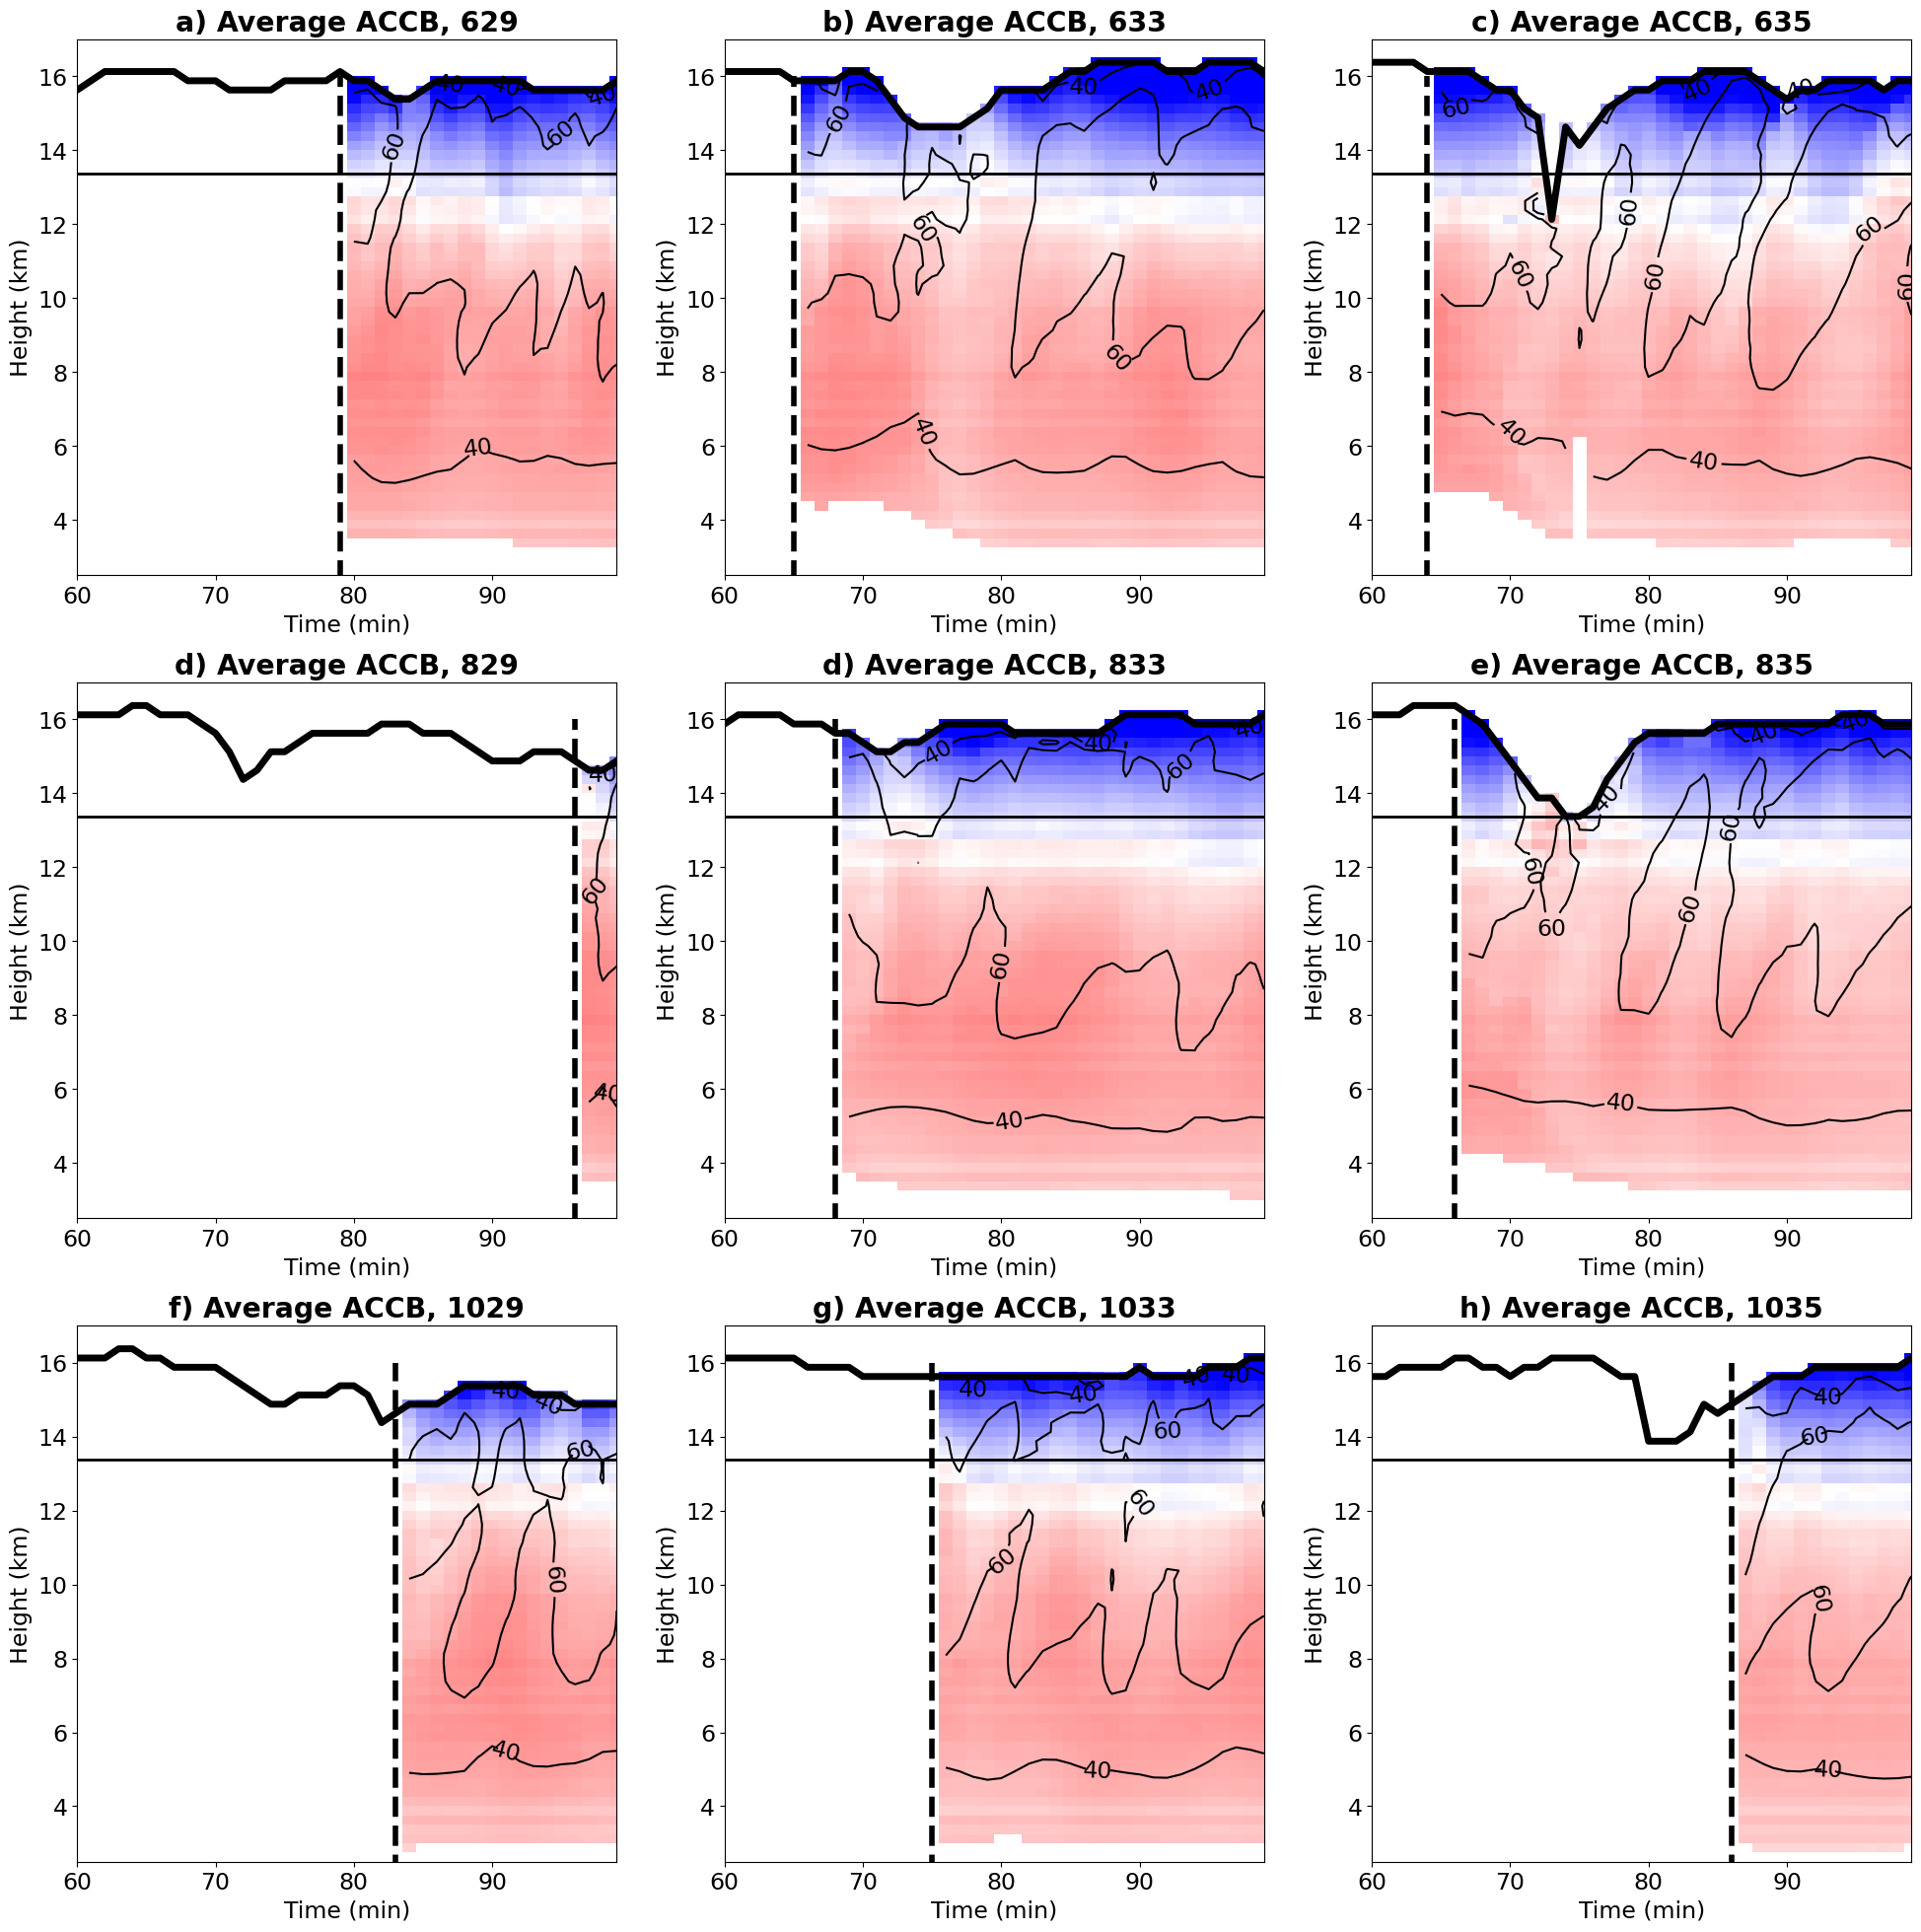

In [20]:
grid_plotting_function(['time', 'hght', 'w_max', 'accbavg_over_polygon'])

# Let's understand how the median value of different characteristics change with height

In [13]:
#1. Let's examine temporal changes to the level of max Zvort median
#Let's get the height of the maximum average zvort at each time step

grouped_zvort_629_max = no_dupes_629.groupby('time')['zvavg_over_polygon'].idxmax()
height_629_max = no_dupes_629.loc[grouped_zvort_629_max]['hght']
grouped_zvort_633_max = no_dupes_633.groupby('time')['zvavg_over_polygon'].idxmax()
height_633_max = no_dupes_633.loc[grouped_zvort_633_max]['hght']
grouped_zvort_635_max = no_dupes_635.groupby('time')['zvavg_over_polygon'].idxmax()
height_635_max = no_dupes_635.loc[grouped_zvort_635_max]['hght']
grouped_zvort_829_max = no_dupes_829.groupby('time')['zvavg_over_polygon'].idxmax()
height_829_max = no_dupes_829.loc[grouped_zvort_829_max]['hght']
grouped_zvort_833_max = no_dupes_833.groupby('time')['zvavg_over_polygon'].idxmax()
height_833_max = no_dupes_833.loc[grouped_zvort_833_max]['hght']
grouped_zvort_835_max = no_dupes_835.groupby('time')['zvavg_over_polygon'].idxmax()
height_835_max = no_dupes_835.loc[grouped_zvort_835_max]['hght']
grouped_zvort_1029_max = no_dupes_1029.groupby('time')['zvavg_over_polygon'].idxmax()
height_1029_max = no_dupes_1029.loc[grouped_zvort_1029_max]['hght']
grouped_zvort_1033_max = no_dupes_1033.groupby('time')['zvavg_over_polygon'].idxmax()
height_1033_max = no_dupes_1033.loc[grouped_zvort_1033_max]['hght']
grouped_zvort_1035_max = no_dupes_1035.groupby('time')['zvavg_over_polygon'].idxmax()
height_1035_max = no_dupes_1035.loc[grouped_zvort_1035_max]['hght']

grouped_zvort_629_min = no_dupes_629.groupby('time')['zvavg_over_polygon'].idxmax()
height_629_min = no_dupes_629.loc[grouped_zvort_629_min]['hght']
grouped_zvort_633_min = no_dupes_633.groupby('time')['zvavg_over_polygon'].idxmax()
height_633_min = no_dupes_633.loc[grouped_zvort_633_min]['hght']
grouped_zvort_635_min = no_dupes_635.groupby('time')['zvavg_over_polygon'].idxmax()
height_635_min = no_dupes_635.loc[grouped_zvort_635_min]['hght']
grouped_zvort_829_min = no_dupes_829.groupby('time')['zvavg_over_polygon'].idxmax()
height_829_min = no_dupes_829.loc[grouped_zvort_829_min]['hght']
grouped_zvort_833_min = no_dupes_833.groupby('time')['zvavg_over_polygon'].idxmax()
height_833_min = no_dupes_833.loc[grouped_zvort_833_min]['hght']
grouped_zvort_835_min = no_dupes_835.groupby('time')['zvavg_over_polygon'].idxmax()
height_835_min = no_dupes_835.loc[grouped_zvort_835_min]['hght']
grouped_zvort_1029_min = no_dupes_1029.groupby('time')['zvavg_over_polygon'].idxmax()
height_1029_min = no_dupes_1029.loc[grouped_zvort_1029_min]['hght']
grouped_zvort_1033_min = no_dupes_1033.groupby('time')['zvavg_over_polygon'].idxmax()
height_1033_min = no_dupes_1033.loc[grouped_zvort_1033_min]['hght']
grouped_zvort_1035_min = no_dupes_1035.groupby('time')['zvavg_over_polygon'].idxmax()
height_1035_min = no_dupes_1035.loc[grouped_zvort_1035_min]['hght']


grouped_time_629 = no_dupes_629.groupby('time')
grouped_time_633 = no_dupes_633.groupby('time')
grouped_time_635 = no_dupes_635.groupby('time')
grouped_time_829 = no_dupes_829.groupby('time')
grouped_time_833 = no_dupes_833.groupby('time')
grouped_time_835 = no_dupes_835.groupby('time')
grouped_time_1029 = no_dupes_1029.groupby('time')
grouped_time_1033 = no_dupes_1033.groupby('time')
grouped_time_1035 = no_dupes_1035.groupby('time')

grouped_height_629 = no_dupes_629.groupby('hght')
grouped_height_633 = no_dupes_633.groupby('hght')
grouped_height_635 = no_dupes_635.groupby('hght')
grouped_height_829 = no_dupes_829.groupby('hght')
grouped_height_833 = no_dupes_833.groupby('hght')
grouped_height_835 = no_dupes_835.groupby('hght')
grouped_height_1029 = no_dupes_1029.groupby('hght')
grouped_height_1033 = no_dupes_1033.groupby('hght')
grouped_height_1035 = no_dupes_1035.groupby('hght')

In [14]:
#Let's create a height diagram of all of the model runs with Zeta

zeta_629_max = grouped_height_629.max()['zvavg_over_polygon']
zeta_633_max = grouped_height_633.max()['zvavg_over_polygon']
zeta_635_max = grouped_height_635.max()['zvavg_over_polygon']

zeta_829_max = grouped_height_829.max()['zvavg_over_polygon']
zeta_833_max = grouped_height_833.max()['zvavg_over_polygon']
zeta_835_max = grouped_height_835.max()['zvavg_over_polygon']

zeta_1029_max = grouped_height_1029.max()['zvavg_over_polygon']
zeta_1033_max = grouped_height_1033.max()['zvavg_over_polygon']
zeta_1035_max = grouped_height_1035.max()['zvavg_over_polygon']

#Let's create a height diagram of all of the model runs with Zeta

zeta_629_min = grouped_height_629.min()['zvavg_over_polygon']
zeta_633_min = grouped_height_633.min()['zvavg_over_polygon']
zeta_635_min = grouped_height_635.min()['zvavg_over_polygon']

zeta_829_min = grouped_height_829.min()['zvavg_over_polygon']
zeta_833_min = grouped_height_833.min()['zvavg_over_polygon']
zeta_835_min = grouped_height_835.min()['zvavg_over_polygon']

zeta_1029_min = grouped_height_1029.min()['zvavg_over_polygon']
zeta_1033_min = grouped_height_1033.min()['zvavg_over_polygon']
zeta_1035_min = grouped_height_1035.min()['zvavg_over_polygon']

#Let's create a height diagram of all of the model runs with Zeta

zeta_629_median = grouped_height_629.median()['zvavg_over_polygon']
zeta_633_median = grouped_height_633.median()['zvavg_over_polygon']
zeta_635_median = grouped_height_635.median()['zvavg_over_polygon']

zeta_829_median = grouped_height_829.median()['zvavg_over_polygon']
zeta_833_median = grouped_height_833.median()['zvavg_over_polygon']
zeta_835_median = grouped_height_835.median()['zvavg_over_polygon']

zeta_1029_median = grouped_height_1029.median()['zvavg_over_polygon']
zeta_1033_median = grouped_height_1033.median()['zvavg_over_polygon']
zeta_1035_median = grouped_height_1035.median()['zvavg_over_polygon']

zeta_629_95 = grouped_height_629.quantile(.95)['zvavg_over_polygon']
zeta_633_95 = grouped_height_633.quantile(.95)['zvavg_over_polygon']
zeta_635_95 = grouped_height_635.quantile(.95)['zvavg_over_polygon']

zeta_829_95 = grouped_height_829.quantile(.95)['zvavg_over_polygon']
zeta_833_95 = grouped_height_833.quantile(.95)['zvavg_over_polygon']
zeta_835_95 = grouped_height_835.quantile(.95)['zvavg_over_polygon']

zeta_1029_95 = grouped_height_1029.quantile(.95)['zvavg_over_polygon']
zeta_1033_95 = grouped_height_1033.quantile(.95)['zvavg_over_polygon']
zeta_1035_95 = grouped_height_1035.quantile(.95)['zvavg_over_polygon']

zeta_629_5 = grouped_height_629.quantile(.05)['zvavg_over_polygon']
zeta_633_5 = grouped_height_633.quantile(.05)['zvavg_over_polygon']
zeta_635_5 = grouped_height_635.quantile(.05)['zvavg_over_polygon']

zeta_829_5 = grouped_height_829.quantile(.05)['zvavg_over_polygon']
zeta_833_5 = grouped_height_833.quantile(.05)['zvavg_over_polygon']
zeta_835_5 = grouped_height_835.quantile(.05)['zvavg_over_polygon']

zeta_1029_5 = grouped_height_1029.quantile(.05)['zvavg_over_polygon']
zeta_1033_5 = grouped_height_1033.quantile(.05)['zvavg_over_polygon']
zeta_1035_5 = grouped_height_1035.quantile(.05)['zvavg_over_polygon']

In [15]:
#Let's find the level of maximum vorticity within the troposphere
zeta_629_max_trop = zeta_629_max[zeta_629_max.index < 8]
zeta_633_max_trop = zeta_633_max[zeta_633_max.index < 8]
zeta_635_max_trop = zeta_635_max[zeta_635_max.index < 8]

zeta_829_max_trop = zeta_829_max[zeta_829_max.index < 8]
zeta_833_max_trop = zeta_833_max[zeta_833_max.index < 8]
zeta_835_max_trop = zeta_835_max[zeta_835_max.index < 8]

zeta_1029_max_trop = zeta_1029_max[zeta_1029_max.index < 8]
zeta_1033_max_trop = zeta_1033_max[zeta_1033_max.index < 8]
zeta_1035_max_trop = zeta_1035_max[zeta_1035_max.index < 8]

zeta_629_min_trop = zeta_629_min[zeta_629_min.index < 8]
zeta_633_min_trop = zeta_633_min[zeta_633_min.index < 8]
zeta_635_min_trop = zeta_635_min[zeta_635_min.index < 8]

zeta_829_min_trop = zeta_829_min[zeta_829_min.index < 8]
zeta_833_min_trop = zeta_833_min[zeta_833_min.index < 8]
zeta_835_min_trop = zeta_835_min[zeta_835_min.index < 8]

zeta_1029_min_trop = zeta_1029_min[zeta_1029_min.index < 8]
zeta_1033_min_trop = zeta_1033_min[zeta_1033_min.index < 8]
zeta_1035_min_trop = zeta_1035_min[zeta_1035_min.index < 8]

zeta_629_median_trop = zeta_629_median[zeta_629_median.index < 8]
zeta_633_median_trop = zeta_633_median[zeta_633_median.index < 8]
zeta_635_median_trop = zeta_635_median[zeta_635_median.index < 8]

zeta_829_median_trop = zeta_829_median[zeta_829_median.index < 8]
zeta_833_median_trop = zeta_833_median[zeta_833_median.index < 8]
zeta_835_median_trop = zeta_835_median[zeta_835_median.index < 8]

zeta_1029_median_trop = zeta_1029_median[zeta_1029_median.index < 8]
zeta_1033_median_trop = zeta_1033_median[zeta_1033_median.index < 8]
zeta_1035_median_trop = zeta_1035_median[zeta_1035_median.index < 8]

In [16]:
#Calculate the average between the min, median and max, find that height and add it to the plot
#pale yellow color if needed: 
avg_629 = np.mean([zeta_629_max_trop, zeta_629_median_trop, zeta_629_min_trop])
avg_629_height = np.mean([zeta_629_median_trop.idxmax(axis = 0, skipna=True), zeta_629_min_trop.idxmax(axis = 0, skipna=True),\
                        zeta_629_max_trop.idxmax(axis = 0, skipna=True)])
avg_633 = np.mean([zeta_633_median_trop, zeta_633_max_trop, zeta_633_min_trop])
avg_633_height = np.mean([zeta_633_median_trop.idxmax(axis = 0, skipna=True), zeta_633_max_trop.idxmax(axis = 0, skipna=True),\
                        zeta_633_min_trop.idxmax(axis = 0, skipna=True)])
avg_635 = np.mean([zeta_635_median_trop, zeta_635_min_trop, zeta_635_max_trop])
avg_635_height = np.mean([zeta_635_median_trop.idxmax(axis = 0, skipna=True), zeta_635_max_trop.idxmax(axis = 0, skipna=True),\
                        zeta_635_min_trop.idxmax(axis = 0, skipna=True)])
#Calculate the average between the min, median and max, find that height and add it to the plot
avg_829 = np.mean([zeta_829_max_trop, zeta_829_median_trop, zeta_829_min_trop])
avg_829_height = np.mean([zeta_829_median_trop.idxmax(axis = 0, skipna=True), zeta_829_min_trop.idxmax(axis = 0, skipna=True),\
                        zeta_829_max_trop.idxmax(axis = 0, skipna=True)])
avg_833 = np.mean([zeta_833_median_trop, zeta_833_max_trop, zeta_833_min_trop])
avg_833_height = np.mean([zeta_833_median_trop.idxmax(axis = 0, skipna=True), zeta_833_max_trop.idxmax(axis = 0, skipna=True),\
                        zeta_833_min_trop.idxmax(axis = 0, skipna=True)])
avg_835 = np.mean([zeta_835_median_trop, zeta_835_min_trop, zeta_835_max_trop])
avg_835_height = np.mean([zeta_835_median_trop.idxmax(axis = 0, skipna=True), zeta_835_max_trop.idxmax(axis = 0, skipna=True),\
                        zeta_835_min_trop.idxmax(axis = 0, skipna=True)])
#Calculate the average between the min, median and max, find that height and add it to the plot
avg_1029 = np.mean([zeta_1029_max_trop, zeta_1029_median_trop, zeta_1029_min_trop])
avg_1029_height = np.mean([zeta_1029_median_trop.idxmax(axis = 0, skipna=True), zeta_1029_min_trop.idxmax(axis = 0, skipna=True),\
                        zeta_1029_max_trop.idxmax(axis = 0, skipna=True)])
avg_1033 = np.mean([zeta_1033_median_trop, zeta_1033_max_trop, zeta_1033_min_trop])
avg_1033_height = np.mean([zeta_1033_median_trop.idxmax(axis = 0, skipna=True), zeta_1033_max_trop.idxmax(axis = 0, skipna=True),\
                        zeta_1033_min_trop.idxmax(axis = 0, skipna=True)])
avg_1035 = np.mean([zeta_1035_median_trop, zeta_1035_min_trop, zeta_1035_max_trop])
avg_1035_height = np.mean([zeta_1035_median_trop.idxmax(axis = 0, skipna=True), zeta_1035_max_trop.idxmax(axis = 0, skipna=True),\
                        zeta_1035_min_trop.idxmax(axis = 0, skipna=True)])

In [17]:
data_6 = {'629':zeta_629_median, '633':zeta_633_median, '635':zeta_635_median}
df_6 = pd.DataFrame(data_6)
median_6 = df_6.mean(axis = 1)
data_8 = {'629':zeta_829_median, '633':zeta_833_median, '635':zeta_835_median}
df_8 = pd.DataFrame(data_8)
median_8 = df_8.mean(axis = 1)
data_10 = {'1029':zeta_1029_median,'1033':zeta_1033_median, '1035':zeta_1035_median}
df_10 = pd.DataFrame(data_10)
median_10 = df_10.mean(axis = 1)

#Diamond Median
med_6_dia_val = np.mean([max(zeta_633_max_trop), max(zeta_629_max_trop), max(zeta_635_max_trop)])
med_6_dia_hgt = np.mean([zeta_635_max_trop.idxmax(), zeta_633_max_trop.idxmax(), zeta_629_max_trop.idxmax()])
med_8_dia_val = np.mean([max(zeta_833_max_trop), max(zeta_829_max_trop), max(zeta_835_max_trop)])
med_8_dia_hgt = np.mean([zeta_835_max_trop.idxmax(), zeta_833_max_trop.idxmax(), zeta_829_max_trop.idxmax()])
med_10_dia_val = np.mean([max(zeta_1029_max_trop), max(zeta_1033_max_trop), max(zeta_1035_max_trop)])
med_10_dia_hgt = np.mean([zeta_1035_max_trop.idxmax(), zeta_1033_max_trop.idxmax(), zeta_1029_max_trop.idxmax()])

Text(0.5, 0.97, 'Updraft Core Average $\\mathbf{\\zeta}$')

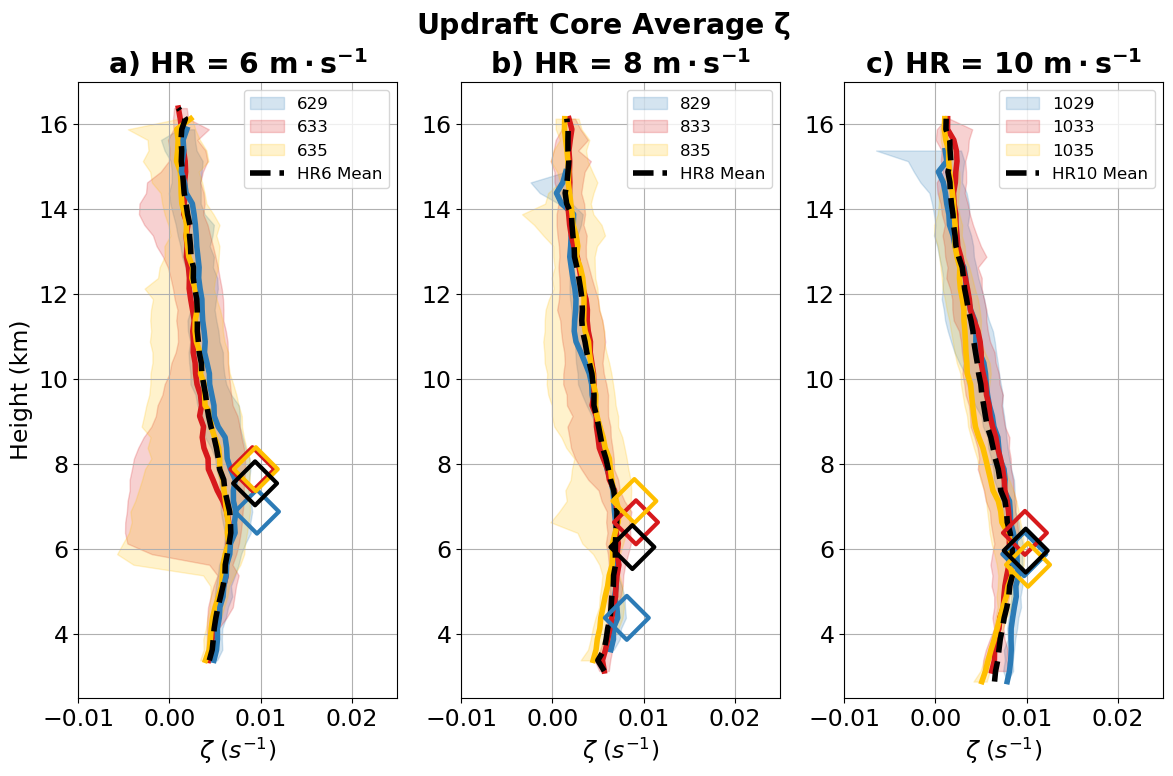

In [18]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (14, 8))
for ax in axes.flat:
    ax.grid(True)
    #(m$\cdot$$s^{-1}$)
    ax.set_xlabel(r'$\zeta$ ($s^{-1}$)')

##Pale yellow hex: '#ffbf00'
axes[0].fill_betweenx(zeta_629_5.index, zeta_629_5, zeta_629_95, color = '#2c7bb6', alpha = 0.2, label = '629',\
                      zorder = 1)
axes[0].plot(zeta_629_median, zeta_629_median.index, color = '#2c7bb6', ls = '-', lw = 4, zorder = 5)
axes[0].scatter(max(zeta_629_max_trop), zeta_629_max_trop.idxmax(), edgecolor = '#2c7bb6', marker = "D", s = 500, zorder = 10,facecolor = 'None', lw = 3)
axes[0].fill_betweenx(zeta_633_5.index, zeta_633_5, zeta_633_95, color = '#d7191c', alpha = 0.2, label = '633',\
                      zorder = 1)
axes[0].plot(zeta_633_median, zeta_633_median.index,  ls = '-', lw = 4, color = '#d7191c')
axes[0].scatter(max(zeta_633_max_trop), zeta_633_max_trop.idxmax(), edgecolor = '#d7191c', marker = "D", s = 500, zorder = 10,facecolor = 'None', lw = 3)
#axes[0].hlines(zeta_633_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#d7191c')
axes[0].fill_betweenx(zeta_635_5.index, zeta_635_5, zeta_635_95, color = '#ffbf00', alpha = 0.2, label = '635')
axes[0].plot(zeta_635_median, zeta_635_median.index,  ls = '-', lw = 4, color = '#ffbf00')
axes[0].scatter(max(zeta_635_max_trop), zeta_635_max_trop.idxmax(), edgecolor = '#ffbf00', marker = "D", s = 500, zorder = 10,facecolor = 'None', lw = 3)
axes[0].scatter(med_6_dia_val, med_6_dia_hgt, edgecolor = 'k', marker = "D", s = 500, zorder = 10,facecolor = 'None', lw = 3)
axes[0].plot(median_6, median_6.index, color = 'k', ls = '--', lw = 4, zorder = 6, label = 'HR6 Mean')
axes[0].set_title(r'a) HR = 6 $\mathrm{\mathbf{m\cdot s^{-1}}}$', weight = 'bold')
axes[0].set_ylabel('Height (km)')
axes[0].legend(loc = 'best', fontsize = 12)

axes[1].fill_betweenx(zeta_829_5.index, zeta_829_5, zeta_829_95, color = '#2c7bb6', alpha = 0.2, label = '829')
axes[1].plot(zeta_829_median, zeta_829_median.index, color = '#2c7bb6', ls = '-', lw = 4)
axes[1].scatter(max(zeta_829_max_trop), zeta_829_max_trop.idxmax(), edgecolor = '#2c7bb6', marker = "D", s = 500, zorder = 10, facecolor = 'None', lw = 3)
axes[1].fill_betweenx(zeta_833_5.index, zeta_833_5, zeta_833_95, color = '#d7191c', alpha = 0.2, label = '833')
axes[1].plot(zeta_833_median, zeta_833_median.index,  ls = '-', lw = 4, color = '#d7191c')
axes[1].scatter(max(zeta_833_max_trop), zeta_833_max_trop.idxmax(), edgecolor = '#d7191c', marker = "D", s = 500, zorder = 10,facecolor = 'None', lw = 3)
#axes[1].hlines(zeta_833_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#d7191c')
axes[1].fill_betweenx(zeta_835_5.index, zeta_835_5, zeta_835_95, color = '#ffbf00', alpha = 0.2, label = '835')
axes[1].plot(zeta_835_median, zeta_835_median.index,  ls = '-', lw = 4, color = '#ffbf00')
axes[1].scatter(max(zeta_835_max_trop), zeta_835_max_trop.idxmax(), edgecolor = '#ffbf00', marker = "D", s = 500, zorder = 10,facecolor = 'None', lw = 3)
axes[1].scatter(med_8_dia_val, med_8_dia_hgt, edgecolor = 'k', marker = "D", s = 500, zorder = 10,facecolor = 'None', lw = 3)
axes[1].plot(median_8, median_8.index, color = 'k', ls = '--', lw = 4, zorder = 6, label = 'HR8 Mean')
axes[1].set_title(r'b) HR = 8 $\mathrm{\mathbf{m\cdot s^{-1}}}$', weight = 'bold')
axes[1].legend(loc = 'best', fontsize = 12)

axes[2].fill_betweenx(zeta_1029_5.index, zeta_1029_5, zeta_1029_95, color = '#2c7bb6', alpha = 0.2, label = '1029')
axes[2].plot(zeta_1029_median, zeta_1029_median.index, color = '#2c7bb6', ls = '-', lw = 4)
axes[2].scatter(max(zeta_1029_max_trop), zeta_1029_max_trop.idxmax(), edgecolor = '#2c7bb6', marker = "D", s = 500, zorder = 10,facecolor = 'None', lw = 3)
axes[2].fill_betweenx(zeta_1033_5.index, zeta_1033_5, zeta_1033_95, color = '#d7191c', alpha = 0.2, label = '1033')
axes[2].plot(zeta_1033_median, zeta_1033_median.index,  ls = '-', lw = 4, color = '#d7191c')
axes[2].scatter(max(zeta_1033_max_trop), zeta_1033_max_trop.idxmax(), edgecolor = '#d7191c', marker = "D", s = 500, zorder = 10,facecolor = 'None', lw = 3)
#axes[2].hlines(zeta_1033_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#d7191c')
axes[2].fill_betweenx(zeta_1035_5.index, zeta_1035_5, zeta_1035_95, color = '#ffbf00', alpha = 0.2, label = '1035')
axes[2].plot(zeta_1035_median, zeta_1035_median.index,  ls = '-', lw = 4, color = '#ffbf00')
axes[2].scatter(max(zeta_1035_max_trop), zeta_1035_max_trop.idxmax(), edgecolor = '#ffbf00', marker = "D", s = 500, zorder = 10,facecolor = 'None', lw = 3)
axes[2].scatter(med_10_dia_val, med_10_dia_hgt, edgecolor = 'k', marker = "D", s = 500, zorder = 10,facecolor = 'None', lw = 3)
axes[2].plot(median_10, median_10.index, color = 'k', ls = '--', lw = 4, zorder = 6, label = 'HR10 Mean')
axes[2].legend(loc = 'best', fontsize = 12)
axes[2].set_title(r'c) HR = 10 $\mathrm{\mathbf{m\cdot s^{-1}}}$', weight = 'bold')

plt.setp((axes), xlim=(-0.01, 0.025), ylim=(2.5, 17))
plt.suptitle(r'Updraft Core Average $\mathbf{\zeta}$', y = 0.97, weight = 'bold')

Text(0.5, 0.93, 'Updraft Core Average $P^\\prime_{b}$')

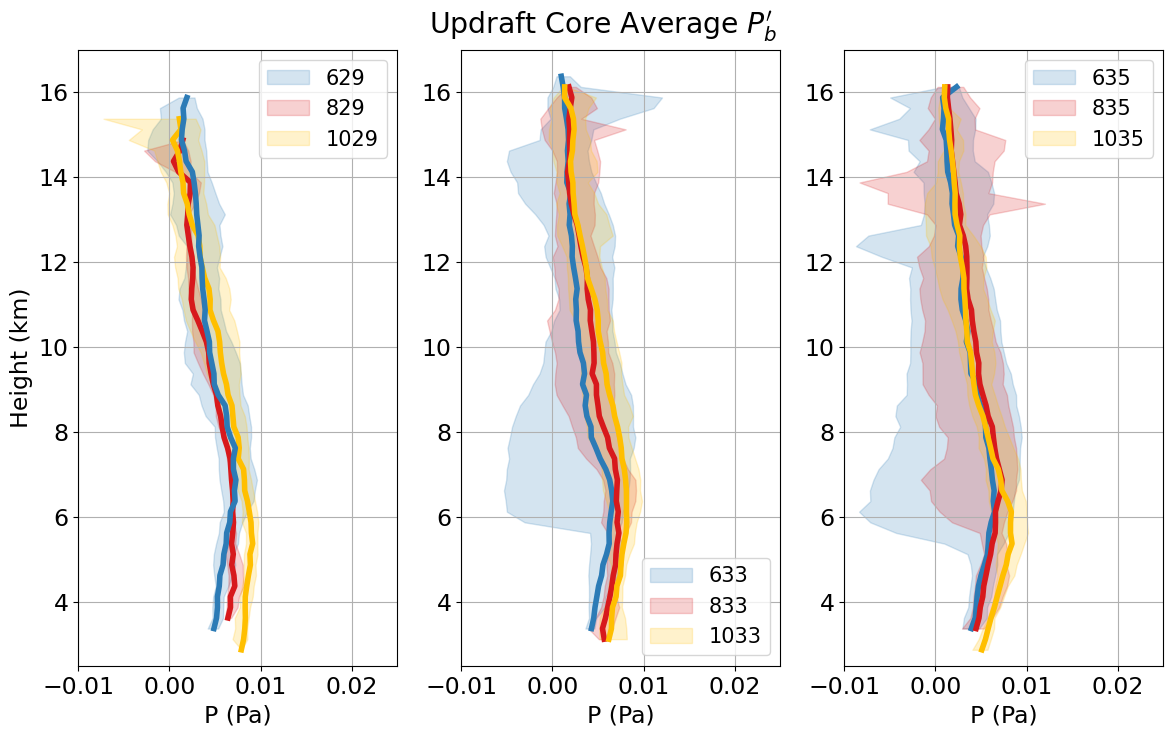

In [19]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (14, 8))
for ax in axes.flat:
    ax.grid(True)
    #(m$\cdot$$s^{-1}$)
    # $\zeta$ ($s^{-1}$)
    ax.set_xlabel(r'P (Pa)')
axes[0].fill_betweenx(zeta_629_max.index, zeta_629_min, zeta_629_max, color = '#2c7bb6', alpha = 0.2, label = '629',\
                      zorder = 1)
axes[0].plot(zeta_629_median, zeta_629_median.index, color = '#2c7bb6', ls = '-', lw = 4, zorder = 5)
#axes[0].scatter(min(zeta_629_median_trop) ,zeta_629_median_trop.idxmax(axis = 0, skipna=True), c = '#2c7bb6', marker = "D",
 #               s = 500, zorder = 10)
#axes[0].hlines(zeta_629_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#2c7bb6')
axes[0].fill_betweenx(zeta_829_max.index, zeta_829_min, zeta_829_max, color = '#d7191c', alpha = 0.2, label = '829',\
                      zorder = 1)
axes[0].plot(zeta_829_median, zeta_829_median.index,  ls = '-', lw = 4, color = '#d7191c')
#axes[0].scatter(min(zeta_829_median_trop) ,zeta_829_median_trop.idxmax(axis = 0, skipna=True), c = '#d7191c', marker = "D",
 #               s = 500, zorder = 10)
#axes[0].hlines(zeta_829_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#d7191c')
axes[0].fill_betweenx(zeta_1029_max.index, zeta_1029_min, zeta_1029_max, color = '#ffbf00', alpha = 0.2, label = '1029')
axes[0].plot(zeta_1029_median, zeta_1029_median.index,  ls = '-', lw = 4, color = '#ffbf00')
#axes[0].scatter(min(zeta_1029_median_trop) ,zeta_1029_median_trop.idxmax(axis = 0, skipna=True), c = '#ffbf00', marker = "D",
 #               s = 500, zorder = 10)
#axes[0].hlines(zeta_1029_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#ffbf00')
axes[0].set_ylabel('Height (km)')
axes[0].legend(loc = 'best', fontsize = 15)

axes[1].fill_betweenx(zeta_633_max.index, zeta_633_min, zeta_633_max, color = '#2c7bb6', alpha = 0.2, label = '633')
axes[1].plot(zeta_633_median, zeta_633_median.index, color = '#2c7bb6', ls = '-', lw = 4)
#axes[1].scatter(min(zeta_633_median_trop) ,zeta_633_median_trop.idxmax(axis = 0, skipna=True), c = '#2c7bb6', marker = "D",
 #               s = 500, zorder = 10)
#axes[1].hlines(zeta_633_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#2c7bb6')
axes[1].fill_betweenx(zeta_833_max.index, zeta_833_min, zeta_833_max, color = '#d7191c', alpha = 0.2, label = '833')
axes[1].plot(zeta_833_median, zeta_833_median.index,  ls = '-', lw = 4, color = '#d7191c')
#axes[1].scatter(min(zeta_833_median_trop) ,zeta_833_median_trop.idxmax(axis = 0, skipna=True), c = '#d7191c', marker = "D",
 #               s = 500, zorder = 10)
#axes[1].hlines(zeta_833_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#d7191c')
axes[1].fill_betweenx(zeta_1033_max.index, zeta_1033_min, zeta_1033_max, color = '#ffbf00', alpha = 0.2, label = '1033')
axes[1].plot(zeta_1033_median, zeta_1033_median.index,  ls = '-', lw = 4, color = '#ffbf00')
#axes[1].scatter(min(zeta_1033_median_trop), zeta_1033_median_trop.idxmax(axis = 0, skipna=True), c = '#ffbf00', marker = "D",
 #               s = 500, zorder = 10)
#axes[1].hlines(zeta_1033_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#ffbf00')
axes[1].legend(loc = 'best', fontsize = 15)

axes[2].fill_betweenx(zeta_635_max.index, zeta_635_min, zeta_635_max, color = '#2c7bb6', alpha = 0.2, label = '635')
axes[2].plot(zeta_635_median, zeta_635_median.index, color = '#2c7bb6', ls = '-', lw = 4)
#axes[2].scatter(min(zeta_635_median_trop) ,zeta_635_median_trop.idxmax(axis = 0, skipna=True), c = '#2c7bb6', marker = "D",
 #               s = 500, zorder = 10)
#axes[2].hlines(zeta_635_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#2c7bb6')
axes[2].fill_betweenx(zeta_835_max.index, zeta_835_min, zeta_835_max, color = '#d7191c', alpha = 0.2, label = '835')
axes[2].plot(zeta_835_median, zeta_835_median.index,  ls = '-', lw = 4, color = '#d7191c')
#axes[2].scatter(min(zeta_835_median_trop) ,zeta_835_median_trop.idxmax(axis = 0, skipna=True), c = '#d7191c', marker = "D",
 #               s = 500, zorder = 10)
#axes[2].hlines(zeta_835_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#d7191c')
axes[2].fill_betweenx(zeta_1035_max.index, zeta_1035_min, zeta_1035_max, color = '#ffbf00', alpha = 0.2, label = '1035')
axes[2].plot(zeta_1035_median, zeta_1035_median.index,  ls = '-', lw = 4, color = '#ffbf00')
#axes[2].scatter(min(zeta_1035_median_trop), zeta_1035_median_trop.idxmax(axis = 0, skipna=True), c = '#ffbf00', marker = "D",
 #               s = 500, zorder = 10)
#axes[2].hlines(zeta_1035_median_trop.idxmax(axis = 0, skipna=True), -200, 200, color = '#ffbf00')
axes[2].legend(loc = 'best', fontsize = 15)

plt.setp((axes),xlim=(-.01, .025), ylim=(2.5, 17))
# $\zeta$
plt.suptitle(r'Updraft Core Average $P^\prime_{b}$', y = 0.93)

In [ ]:
avg6 = np.mean(np.array([min(zeta_629_median_trop), min(zeta_633_median_trop), min(zeta_635_median_trop),\
                min(zeta_629_max_trop), min(zeta_633_max_trop), min(zeta_635_max_trop), \
                min(zeta_629_min_trop), min(zeta_633_min_trop), min(zeta_635_min_trop)]))
height6 = np.mean(np.array([zeta_629_median_trop.idxmin(axis = 0, skipna=True), zeta_633_median_trop.idxmin(axis = 0, skipna=True),\
    zeta_635_median_trop.idxmin(axis = 0, skipna=True), zeta_629_max_trop.idxmin(axis = 0, skipna=True), zeta_633_max_trop.idxmin(axis = 0, skipna=True),\
    zeta_635_max_trop.idxmin(axis = 0, skipna=True), zeta_629_min_trop.idxmin(axis = 0, skipna=True), zeta_633_min_trop.idxmin(axis = 0, skipna=True),\
    zeta_635_min_trop.idxmin(axis = 0, skipna=True)]))

print(avg6/100, height6)

-7.408667071205332e-06 14.12500061111111


In [ ]:
#Calculate the slope of the lines before and after the critical level
before_629_max = zeta_629_max_trop[:zeta_629_max_trop.idxmin(axis = 0, skipna=True)]
after_629_max = zeta_629_max_trop[zeta_629_max_trop.idxmin(axis = 0, skipna=True):]
before_629_median = zeta_629_median_trop[:zeta_629_median_trop.idxmin(axis = 0, skipna=True)]
after_629_median = zeta_629_median_trop[zeta_629_max_trop.idxmin(axis = 0, skipna=True):] 
before_629_min = zeta_629_min_trop[:zeta_629_min_trop.idxmin(axis = 0, skipna=True)] 
after_629_min = zeta_629_min_trop[zeta_629_max_trop.idxmin(axis = 0, skipna=True):]
before_633_median = zeta_633_median_trop[:zeta_633_median_trop.idxmin(axis = 0, skipna=True)]
after_633_median = zeta_633_median_trop[zeta_633_median_trop.idxmin(axis = 0, skipna=True):]
before_633_max = zeta_633_max_trop[:zeta_633_max_trop.idxmin(axis = 0, skipna=True)] 
after_633_max = zeta_633_max_trop[zeta_633_max_trop.idxmin(axis = 0, skipna=True):] 
before_633_min = zeta_633_min_trop[:zeta_633_max_trop.idxmin(axis = 0, skipna=True)]  
after_633_min = zeta_633_max_trop[zeta_633_max_trop.idxmin(axis = 0, skipna=True):] 
before_635_median = zeta_635_median_trop[:zeta_635_median_trop.idxmin(axis = 0, skipna=True)]
after_635_median = zeta_635_median_trop[zeta_635_median_trop.idxmin(axis = 0, skipna=True):]
before_635_max = zeta_635_max_trop[:zeta_635_max_trop.idxmin(axis = 0, skipna=True)]
after_635_max = zeta_635_max_trop[zeta_635_max_trop.idxmin(axis = 0, skipna=True):]
before_635_min = zeta_635_min_trop[:zeta_635_min_trop.idxmin(axis = 0, skipna=True)] 
after_635_min = zeta_635_min_trop[zeta_635_min_trop.idxmin(axis = 0, skipna=True):] 

In [ ]:
#Calculate the slope of each line
before_629_slope_min, *rest = linregress(before_629_min.values, before_629_min.index)
before_633_slope_min, *rest = linregress(before_633_min.values, before_633_min.index)
before_635_slope_min, *rest = linregress(before_635_min.values, before_635_min.index)
avg_before_slope_min = np.mean(np.array([before_629_slope_min, before_633_slope_min, before_635_slope_min]))
after_629_slope_min, *rest = linregress(after_629_min.values, after_629_min.index)
after_633_slope_min, *rest = linregress(after_633_min.values, after_633_min.index)
after_635_slope_min, *rest = linregress(after_635_min.values, after_635_min.index)
avg_after_slope_min = np.mean(np.array([after_629_slope_min, after_633_slope_min, after_635_slope_min]))

#Calculate the slope of each line
before_629_slope_median, *rest = linregress(before_629_median.values, before_629_median.index)
before_633_slope_median, *rest = linregress(before_633_median.values, before_633_median.index)
before_635_slope_median, *rest = linregress(before_635_median.values, before_635_median.index)
avg_before_slope_median = np.mean(np.array([before_629_slope_median, before_633_slope_median, before_635_slope_median]))
after_629_slope_median, *rest = linregress(after_629_median.values, after_629_median.index)
after_633_slope_median, *rest = linregress(after_633_median.values, after_633_median.index)
after_635_slope_median, *rest = linregress(after_635_median.values, after_635_median.index)
avg_after_slope_median = np.mean(np.array([after_629_slope_median, after_633_slope_median, after_635_slope_median]))
#Calculate the slope of each line
before_629_slope_max, *rest = linregress(before_629_max.values, before_629_max.index)
before_633_slope_max, *rest = linregress(before_633_max.values, before_633_max.index)
before_635_slope_max, *rest = linregress(before_635_max.values, before_635_max.index)
avg_before_slope_max = np.mean(np.array([before_629_slope_max, before_633_slope_max, before_635_slope_max]))
after_629_slope_max, *rest = linregress(after_629_max.values, after_629_max.index)
after_633_slope_max, *rest = linregress(after_633_max.values, after_633_max.index)
after_635_slope_max, *rest = linregress(after_635_max.values, after_635_max.index)
avg_after_slope_max = np.mean(np.array([after_629_slope_max, after_633_slope_max, after_635_slope_max]))

In [73]:
np.mean(np.array([avg_before_slope_min, avg_before_slope_max, avg_before_slope_median])), np.mean(np.array([avg_after_slope_max, avg_after_slope_median, avg_after_slope_median]))

(np.float64(-0.041128315211817416), np.float64(0.03810298879015356))